In [72]:
import trafpy.generator as tpg

In [73]:
num_eps = 4

In [74]:
racks_dict, num_racks = {}, 2
eps_per_rack = int(num_eps/num_racks)
for rack in range(num_racks):
    racks_dict[rack] = [ep for ep in range(rack*eps_per_rack, (rack*eps_per_rack)+eps_per_rack)]
print(racks_dict)

{0: [0, 1], 1: [2, 3]}


In [75]:
ep_capacity = 1000000000

In [76]:
net = tpg.gen_arbitrary_network(num_eps=num_eps, ep_capacity=ep_capacity, racks_dict=racks_dict)

In [77]:
print(net.graph.keys())
print(net.graph['topology_type'])

dict_keys(['endpoints', 'endpoint_label', 'num_channels_per_link', 'ep_link_capacity', 'ep_link_port_capacity', 'max_nw_capacity', 'curr_nw_capacity_used', 'num_active_connections', 'total_connections_blocked', 'node_labels', 'topology_type', 'channel_names', 'rack_to_ep_dict', 'ep_to_rack_dict'])
arbitrary_endpoints_4_chancap_100000000_channels_1


In [78]:
print("max_nw_capacity:", net.graph['max_nw_capacity'])
print("topology_type:", net.graph['topology_type'])
print("endpoints:", net.graph['endpoints'])
print("endpoint_label:", net.graph['endpoint_label'])
print("num_channels_per_link:", net.graph['num_channels_per_link'])
print("ep_link_capacity:", net.graph['ep_link_capacity'])
print("ep_link_port_capacity:", net.graph['ep_link_port_capacity'])
print("curr_nw_capacity_used:", net.graph['curr_nw_capacity_used'])
print("num_active_connections:", net.graph['num_active_connections'])
print("total_connections_blocked:", net.graph['total_connections_blocked'])
print("node_labels:", net.graph['node_labels'])
print("channel_names:", net.graph['channel_names'])
print("rack_to_ep_dict:", net.graph['rack_to_ep_dict'])
print("ep_to_rack_dict:", net.graph['ep_to_rack_dict'])


max_nw_capacity: 200000000.0
topology_type: arbitrary_endpoints_4_chancap_100000000_channels_1
endpoints: ['0', '1', '2', '3']
endpoint_label: None
num_channels_per_link: 1
ep_link_capacity: 100000000
ep_link_port_capacity: 50000000.0
curr_nw_capacity_used: 0
num_active_connections: 0
total_connections_blocked: 0
node_labels: [None]
channel_names: ['channel_1']
rack_to_ep_dict: {'0': ['0', '1'], '1': ['2', '3']}
ep_to_rack_dict: {'0': '0', '1': '0', '2': '1', '3': '1'}


In [79]:
network_load_config = {'network_rate_capacity': net.graph['max_nw_capacity'], 
                       'ep_link_capacity': net.graph['ep_link_capacity'],
                       'target_load_fraction': 0.4}

In [80]:
dists = {}
dists['node_dist'] = tpg.gen_uniform_node_dist(eps=net.graph['endpoints'])
#dists['interarrival_time_dist'] = {1.0: 1.0}
#dists['flow_size_dist'] = {1.0: 1.0}

In [81]:
"""
rand_var = tpg.gen_named_val_dist(dist='lognormal',
                              params={'_mu': 6, '_sigma': 4},  #9,3.5    ;    6,4      
                              min_val=1,
                              max_val=1e9,
                              round_to_nearest=2,
                              show_fig=False,
                              plot_fig=False,
                              logscale=False,
                                size=100000,
                              print_data=False)
                              """

"\nrand_var = tpg.gen_named_val_dist(dist='lognormal',\n                              params={'_mu': 6, '_sigma': 4},  #9,3.5    ;    6,4      \n                              min_val=1,\n                              max_val=1e9,\n                              round_to_nearest=2,\n                              show_fig=False,\n                              plot_fig=False,\n                              logscale=False,\n                                size=100000,\n                              print_data=False)\n                              "

In [82]:
#rand_var = tpg.gen_named_val_dist(dist='weibull',
 #                             params={'_alpha': 0.4, '_lambda': 5000},
  #                            min_val=1,
   #                           max_val=1e9,
    #                         # xlim=[0,80000],
     #                         round_to_nearest=25,
      #                        show_fig=False,
       #                         size=15000,
        #                      plot_fig=False,
         #                     print_data=False)

In [83]:
rand_var = tpg.gen_named_val_dist(dist='pareto',
                              interactive_plot=False,
                              params={'_alpha': 0.05, '_mode': 0.1},   #0.05,1     
                              min_val=1,
                              max_val=1e9,
                              round_to_nearest=None,
                              size=15000,
                              rand_var_name='Random Variable')

In [84]:
dists['flow_size_dist'] = rand_var

In [85]:
"""dist = tpg.gen_named_val_dist(dist='weibull',
                              params={'_alpha': 0.9, '_lambda': 6000},
                              min_val=1,
                              max_val=80000,
                             # xlim=[0,80000],
                              round_to_nearest=25,
                              show_fig=False,
                              plot_fig=False,
                              print_data=False)"""

"dist = tpg.gen_named_val_dist(dist='weibull',\n                              params={'_alpha': 0.9, '_lambda': 6000},\n                              min_val=1,\n                              max_val=80000,\n                             # xlim=[0,80000],\n                              round_to_nearest=25,\n                              show_fig=False,\n                              plot_fig=False,\n                              print_data=False)"

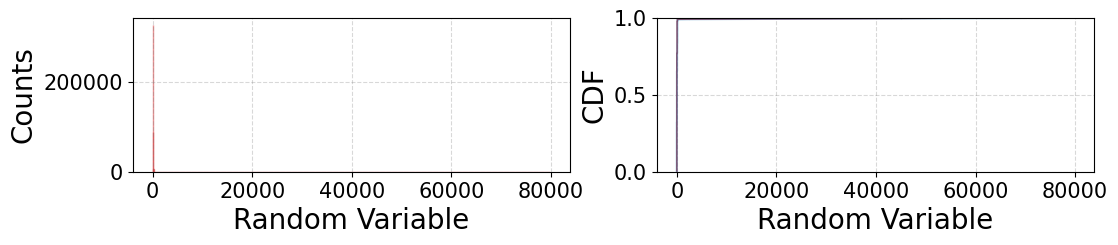

In [86]:
dist = tpg.gen_multimodal_val_dist(min_val=1,
                                   show_fig=True,
                        #           xlim=[0,80000],
                                   max_val=80000,
                                   locations=[10,20,100,1],
                                   skews=[0,0,0,100],
                                   scales=[1,3,4,50],
                                   num_skew_samples=[10000,7000,5000,20000],
                                   round_to_nearest=25,
                                   bg_factor=0.01)

In [87]:
"""dist = tpg.gen_multimodal_val_dist(min_val=1,
                                   show_fig=True,
                                #   xlim=[0,80000],
                                   max_val=80000,
                                   locations=[40,1],
                                   skews=[-1,4],
                                   scales=[60,1000],
                                   num_skew_samples=[10000,10000],
                                   round_to_nearest=25,
                                   bg_factor=0.05)"""

'dist = tpg.gen_multimodal_val_dist(min_val=1,\n                                   show_fig=True,\n                                #   xlim=[0,80000],\n                                   max_val=80000,\n                                   locations=[40,1],\n                                   skews=[-1,4],\n                                   scales=[60,1000],\n                                   num_skew_samples=[10000,10000],\n                                   round_to_nearest=25,\n                                   bg_factor=0.05)'

In [88]:
dists['interarrival_time_dist'] = dist

In [89]:
jsd_threshold = 0.9

In [90]:
from pathlib import Path
import gzip
import pickle
import time

path_to_data = 'data/final_try/'
Path(path_to_data).mkdir(exist_ok=True, parents=True)

print('Generating \'{}\' traffic demands for {} network'.format(dists, net.graph['topology_type']))
    
# get node, flow size, and flow inter-arrival time benchmark dists
#dists = dcn_dist
    
# generate traffic demands
demand_data = tpg.create_demand_data(eps=net.graph['endpoints'],
                                     node_dist=dists['node_dist'],
                                     flow_size_dist=dists['flow_size_dist'],
                                     interarrival_time_dist=dists['interarrival_time_dist'],
                                     network_load_config=network_load_config,
                                     jensen_shannon_distance_threshold=jsd_threshold)
                                   #  min_last_demand_arrival_time=2)
    
    # save demands as pickle file
    # filename = path_to_data+'{}_demand_data.pickle'.format(dcn)
    # with gzip.open(filename, 'wb') as f:
    #     pickle.dump(demand_data, f)

#tpg.save_data_as_csv(data=demand_data,path_to_save=path_to_data+'First_try_40.csv',overwrite=True)

Generating '{'node_dist': array([[0.        , 0.08333333, 0.08333333, 0.08333333],
       [0.08333333, 0.        , 0.08333333, 0.08333333],
       [0.08333333, 0.08333333, 0.        , 0.08333333],
       [0.08333333, 0.08333333, 0.08333333, 0.        ]]), 'flow_size_dist': {np.float64(37946295.374304995): 6.666666666666667e-05, np.float64(7049165.183285892): 6.666666666666667e-05, np.float64(975875.4568070412): 6.666666666666667e-05, np.float64(2281.4892780833748): 6.666666666666667e-05, np.float64(127109167.27447528): 6.666666666666667e-05, np.float64(46801.34223098403): 6.666666666666667e-05, np.float64(4181550.214887956): 6.666666666666667e-05, np.float64(229.71434856551934): 6.666666666666667e-05, np.float64(55902.030077484604): 6.666666666666667e-05, np.float64(17449930.6605266): 6.666666666666667e-05, np.float64(108.8846174974711): 6.666666666666667e-05, np.float64(2.263420348146242): 6.666666666666667e-05, np.float64(6.683115751186576): 6.666666666666667e-05, np.float64(14371495

AttributeError: 'tuple' object has no attribute 'keys'

In [91]:
tpg.save_data_as_csv(data=demand_data,path_to_save=path_to_data+'First_try_40_com.csv',overwrite=True)

Time to save data to data/final_try/First_try_40_com.csv: 0.02516317367553711 s
